In [1]:
# Watershed is an image segmentation algorithm that treats pixel intensity as elevation (like a topographic map). Here's how it works:
# Concept — imagine flooding a landscape from the lowest points. Where two "flood regions" would merge, a watershed boundary (dam) is built. Those dams become the segment borders.
# Problem it solves — separating touching or overlapping objects that a simple threshold can't split (e.g., coins touching each other).

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def display(img, cmap='gray'):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

In [3]:
sep_point = cv.imread('../data/pennies.jpg')

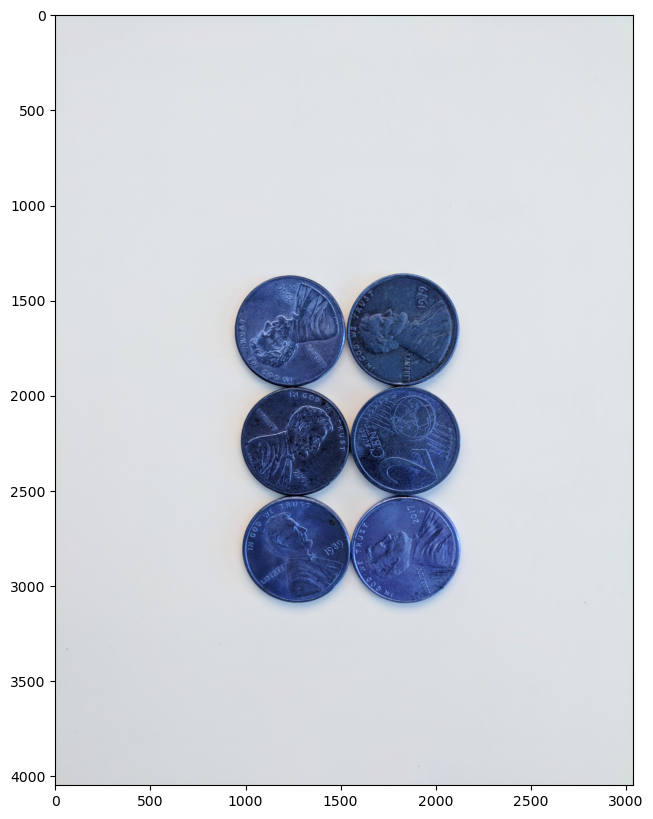

In [4]:
display(sep_point)

In [5]:
# Medium blurr
sep_blur = cv.medianBlur(sep_point, 25)
sep_blur = cv.cvtColor(sep_blur, cv.COLOR_BGR2GRAY)

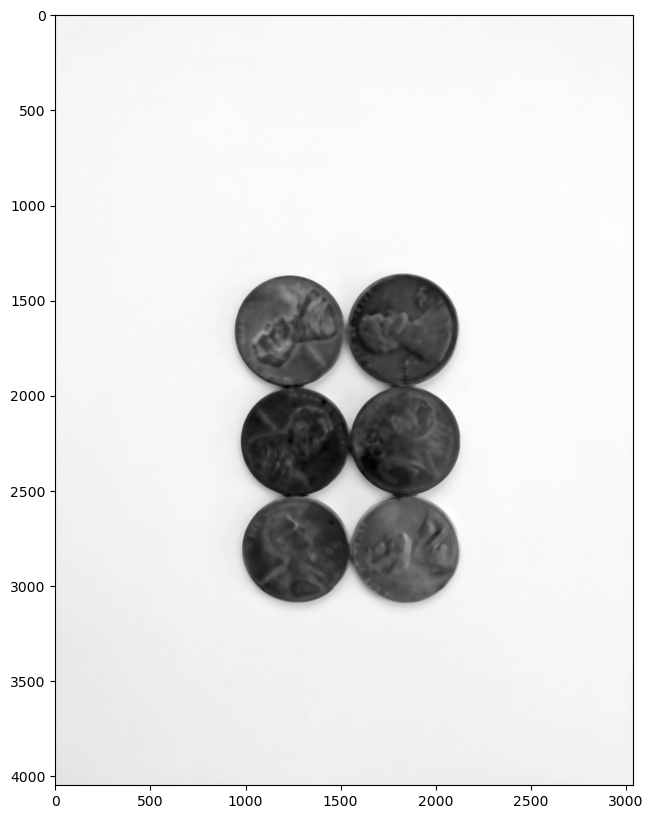

In [6]:
display(sep_blur)

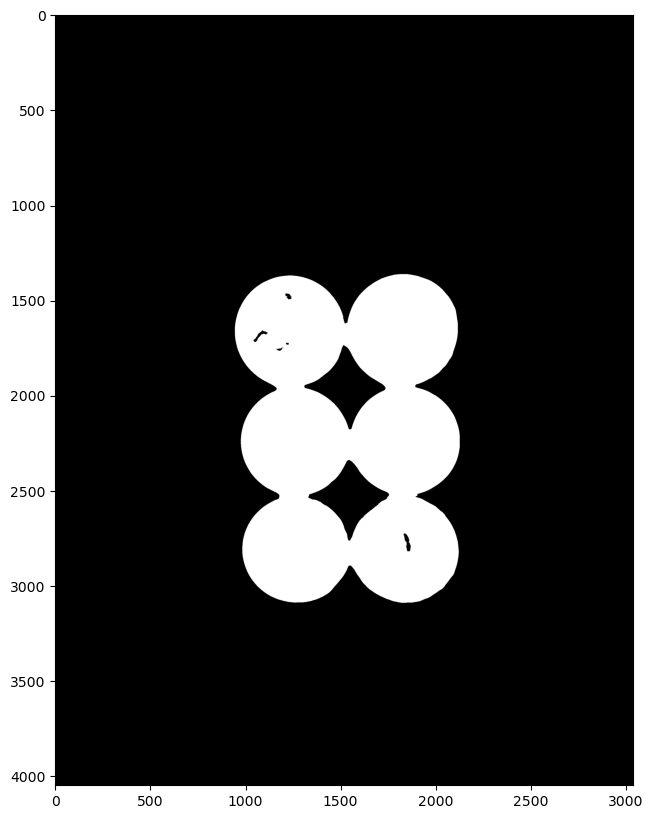

In [7]:
# Binary threshold
ret, sep_thresh = cv.threshold(sep_blur, 140, 255, cv.THRESH_BINARY_INV)
display(sep_thresh)

In [8]:
contours, hierarchy = cv.findContours(sep_thresh.copy(), cv.RETR_CCOMP, cv.CHAIN_APPROX_SIMPLE)

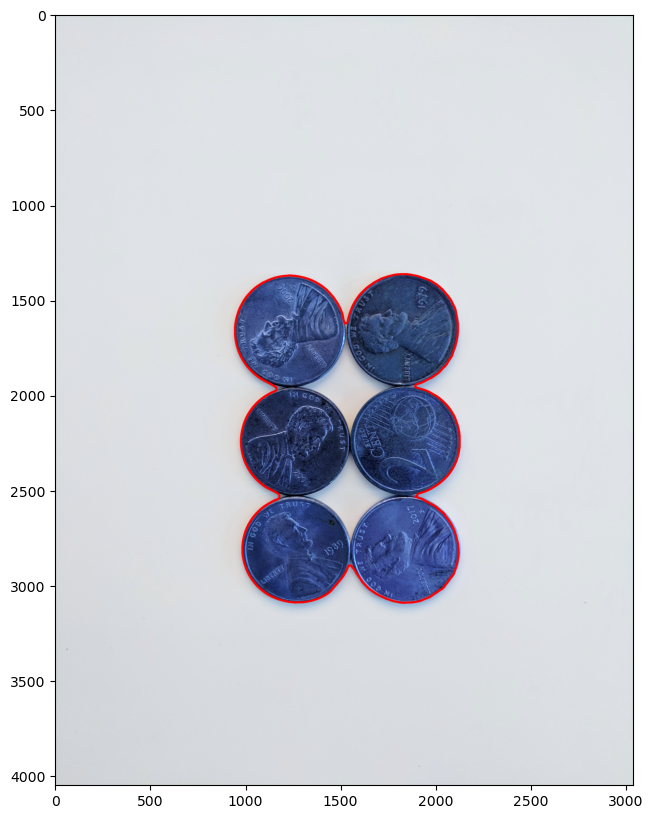

In [9]:
for i in range(len(contours)):
    if hierarchy[0][i][3] == -1:
        cv.drawContours(sep_point, contours, i, (255,0,0),10)

display(sep_point)

In [10]:
img = cv.imread('../data/pennies.jpg')

In [11]:
img = cv.medianBlur(img, ksize=35)

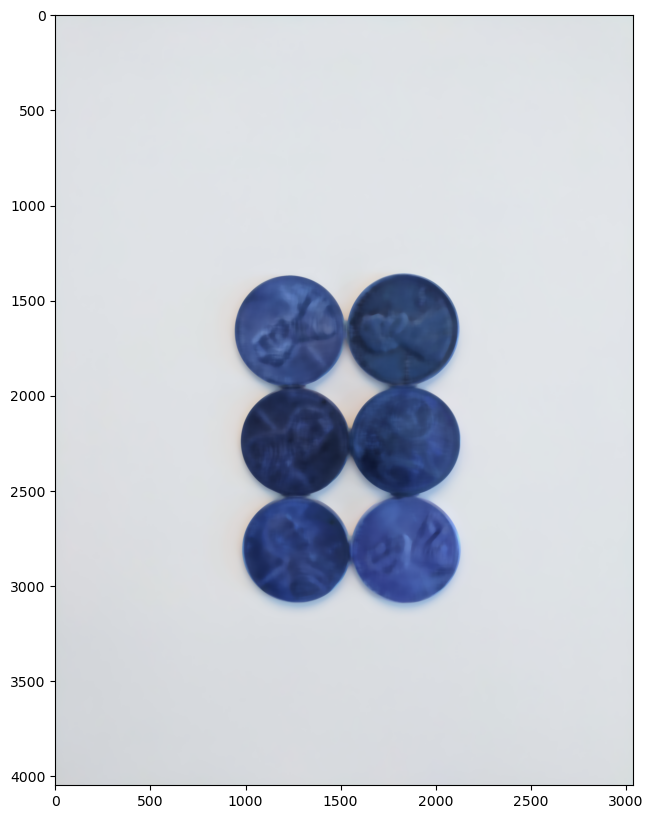

In [12]:
display(img)

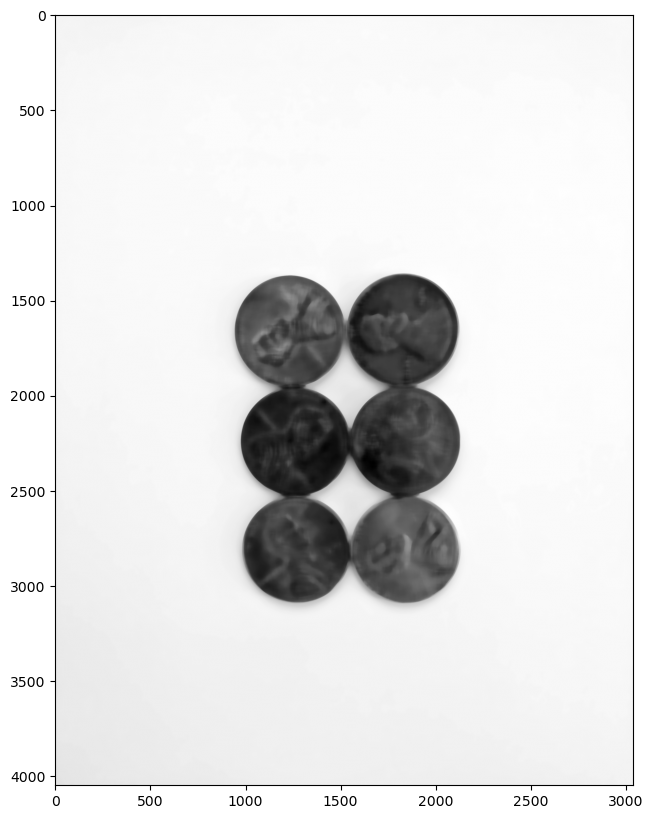

In [13]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
display(gray)

In [14]:
ret, thresh = cv.threshold(gray, 150, 255, cv.THRESH_BINARY_INV)

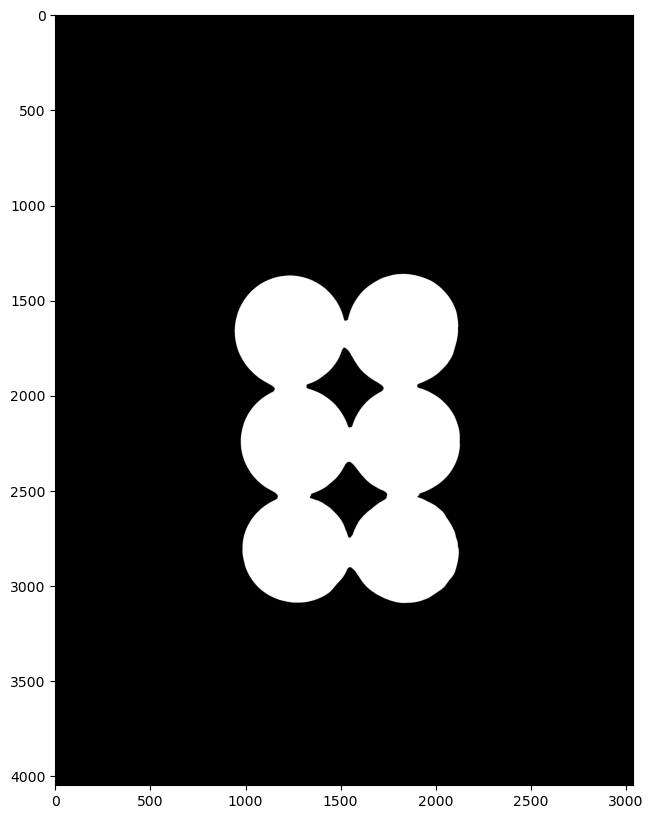

In [15]:
display(thresh)

In [16]:
# NOISE REMOVAL
kernel = np.ones((3,3), np.uint8)

In [17]:
kernel

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8)

In [18]:
opening = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel=kernel)

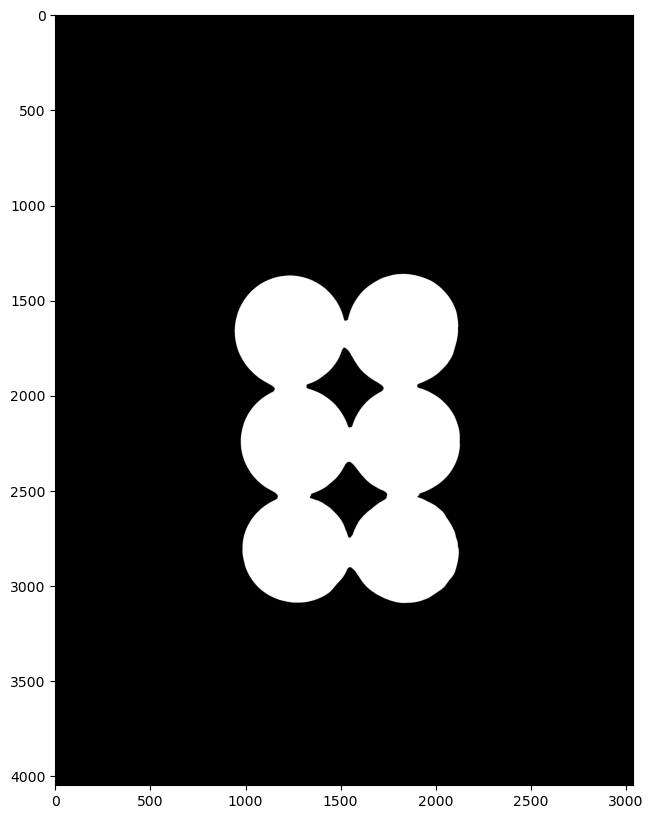

In [19]:
display(opening)

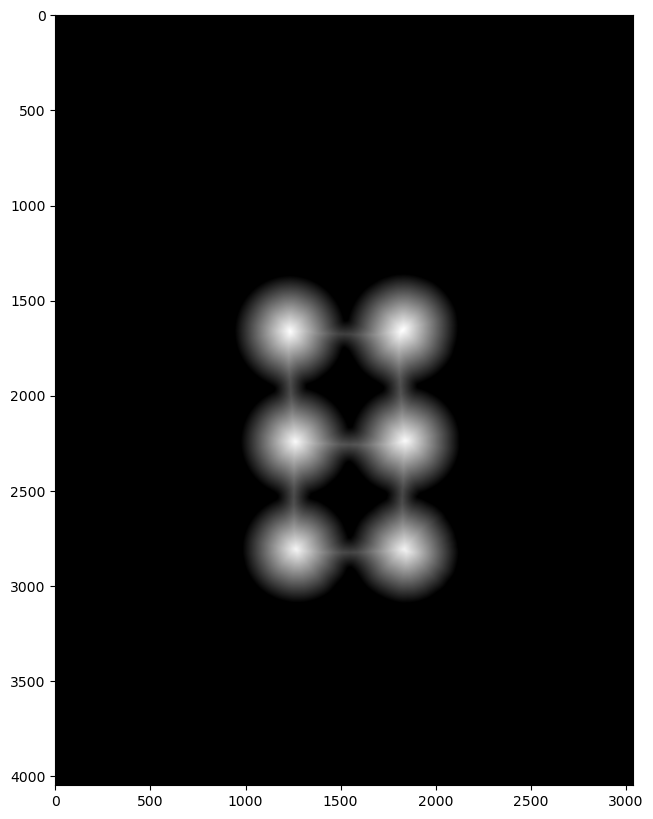

In [20]:
dist_transform = cv.distanceTransform(opening, cv.DIST_L2, 5)
display(dist_transform)

In [21]:
ret, sure_fg = cv.threshold(dist_transform, 0.7*dist_transform.max(),255,0)

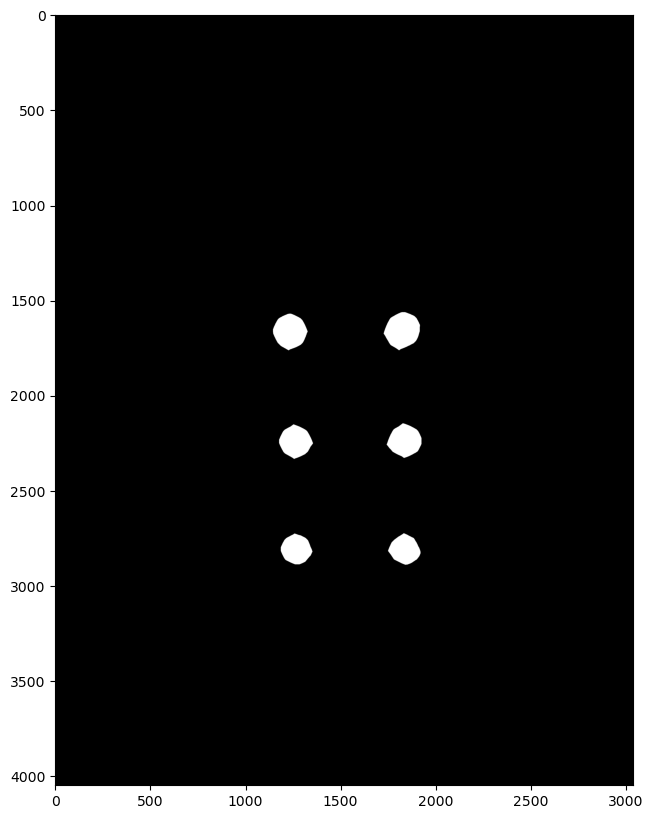

In [22]:
display(sure_fg)

In [23]:
sure_fg = np.uint8(sure_fg)
sure_bg = cv.dilate(opening, kernel, iterations=3)

In [24]:
unknown = cv.subtract(sure_bg, sure_fg)

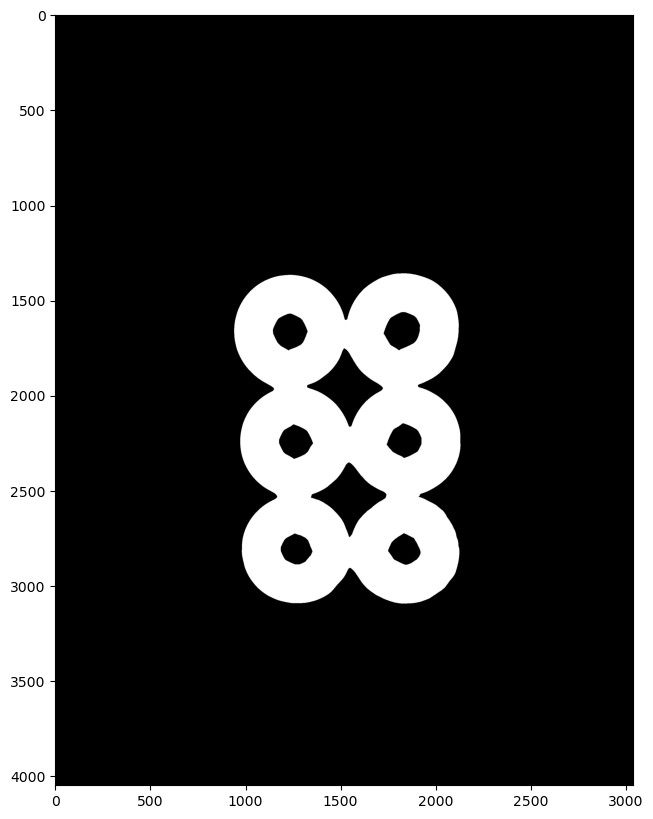

In [25]:
display(unknown)

In [26]:
ret, markers = cv.connectedComponents(sure_fg)

In [27]:
markers = markers + 1

In [28]:
markers

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(4048, 3036), dtype=int32)

In [29]:
markers[unknown==255] = 0

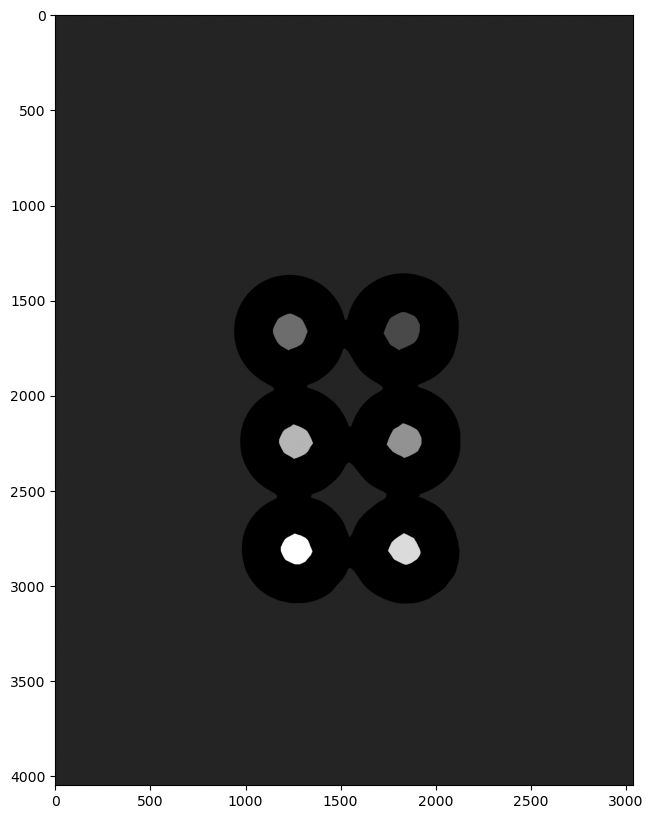

In [30]:
display(markers)

In [31]:
road = cv.imread('../data/road_image.jpg')

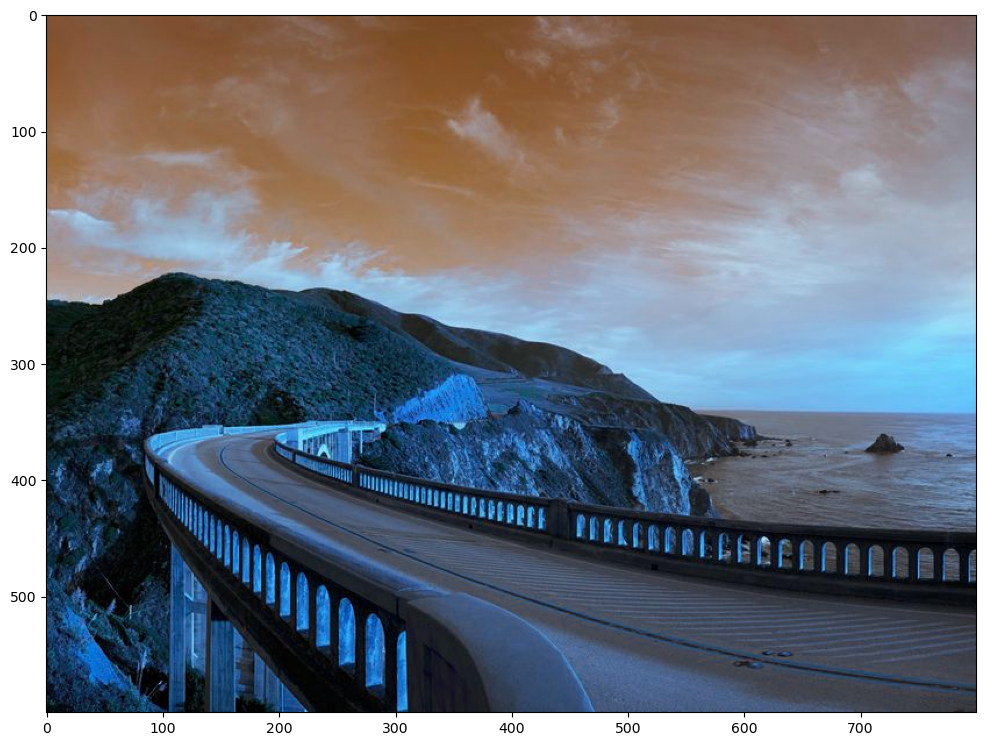

In [32]:
display(road)

In [33]:
road_copy = np.copy(road)
# plt.imshow(road_copy)

In [34]:
road.shape[:2]

(600, 800)

In [35]:
marker_img = np.zeros(road.shape[:2], dtype=np.uint32)

In [36]:
segments = np.zeros(road.shape, dtype=np.uint8)

In [37]:
marker_img.shape

(600, 800)

In [38]:
segments.shape

(600, 800, 3)

In [39]:
from matplotlib import cm

In [40]:
cm.tab10(0)

(np.float64(0.12156862745098039),
 np.float64(0.4666666666666667),
 np.float64(0.7058823529411765),
 np.float64(1.0))

In [41]:
def create_rgb(i):
    return tuple(np.array(cm.tab10(i)[:3])*255)


In [42]:
colors = []
for i in range(10):
    colors.append(create_rgb(i))

In [43]:
colors

[(np.float64(31.0), np.float64(119.0), np.float64(180.0)),
 (np.float64(255.0), np.float64(127.0), np.float64(14.0)),
 (np.float64(44.0), np.float64(160.0), np.float64(44.0)),
 (np.float64(214.0), np.float64(39.0), np.float64(40.0)),
 (np.float64(148.0), np.float64(103.0), np.float64(189.0)),
 (np.float64(140.0), np.float64(86.0), np.float64(75.0)),
 (np.float64(227.0), np.float64(119.0), np.float64(194.0)),
 (np.float64(127.0), np.float64(127.0), np.float64(127.0)),
 (np.float64(188.0), np.float64(189.0), np.float64(34.0)),
 (np.float64(23.0), np.float64(190.0), np.float64(207.0))]

In [44]:
## GLOBAL VARIABLES
current_marker = 1
marks_updated = False
n_markers = 10 #0-9

In [45]:
## CALLBACK FUNCTION
def mouse_callback(event, x, y, flags, param):
    global marks_updated
    if event == cv.EVENT_LBUTTONDOWN:
        # MARKERS passed to watershed algo
        cv.circle(marker_img,(x,y,),10,(current_marker),-1)
        
        # USERS sees on road image
        cv.circle(road_copy,(x,y),10,[current_marker],-1)

        marks_updated = True


In [ ]:
## WHILE TRUE
cv.namedWindow('Road Image')
cv.setMouseCallback('Road Image', mouse_callback)

while True:
    cv.imshow('Watershed Algorithm', segments)
    cv.imshow('Road Image', road_copy)

    k = cv.waitKey(1) & 0xFF

    # Close all windows
    if k == 27:
        break

    # Clear all colors upon 'c' key
    elif k == ord('c'):
        road_copy = road.copy()
        marker_img = np.zeros(road.shape[:2], dtype=np.int32)
        segments = np.zeros(road.shape, dtype=np.uint8)

    # Update color choice with digit key
    elif chr(k).isdigit():
        current_marker = int(chr(k))

    # Update markings only when new mark is drawn
    if marks_updated:
        marker_img_copy = marker_img.copy()
        cv.watershed(road, marker_img_copy)

        segments = np.zeros(road.shape, dtype=np.uint8)

        for color_ind in range(n_markers):
            segments[marker_img_copy == color_ind] = colors[color_ind]

        marks_updated = False  # reset flag

cv.destroyAllWindows()

error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'circle'
> Overload resolution failed:
>  - img data type = uint32 is not supported
>  - Expected Ptr<cv::UMat> for argument 'img'


error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'circle'
> Overload resolution failed:
>  - img data type = uint32 is not supported
>  - Expected Ptr<cv::UMat> for argument 'img'


error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'circle'
> Overload resolution failed:
>  - img data type = uint32 is not supported
>  - Expected Ptr<cv::UMat> for argument 'img'
